# 2. Optimizer behavior and measured cost

This illustrative comparison puts RHC, SA, GA, and Adam on the same small
classification and regression tasks. It is designed to reveal characteristic
training signatures, not rank optimizers or establish a benchmark.

Each task uses 360 generated observations, a fixed 75/25 train/validation split,
training-only standardization, a tanh network with hidden width 8, and three paired
initialization seeds. Runs use float32 CPU, one Torch thread, full-batch loss, and
160 optimizer calls. Fixed call counts, objective evaluations, backward work, and
elapsed time are not equivalent budgets.

In [1]:
import importlib.metadata
import platform
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    "Versions:",
    {
        package: importlib.metadata.version(package)
        for package in [
            "pyperch",
            "torch",
            "numpy",
            "matplotlib",
            "scikit-learn",
            "optuna",
        ]
    },
)

Python 3.12.13 | Darwin arm64
Versions: {'pyperch': '0.3.2', 'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}


## Record current loss, checkpoints, and cost

Call 0 records the initial model. RHC and SA use their first call to initialize
loss, GA uses its first call to evaluate a complete population, and Adam updates on
its first call. Later GA calls evolve its retained population by one generation.

`function_evals` counts optimizer closure calls. Two extra monitoring forwards per
point record train and validation curves, and Adam also performs a backward pass.
Final metrics come from each run's lowest training-loss checkpoint, restored without
selecting on validation.

In [2]:
from copy import deepcopy

from IPython.display import Markdown, display
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import f1_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyperch.optim import GA, RHC, SA
from pyperch.plotting import plot_training_curve, prepare_training_curve

SEEDS = [11, 22, 33]
CALLS = 160
names = ["RHC", "SA", "GA", "Adam"]
settings = {
    "RHC": {"step_size": 0.06},
    "SA": {
        "step_size": 0.15,
        "temperature": 0.20,
        "min_temperature": 0.002,
        "cooling": 0.96,
    },
    "GA": {
        "population_size": 16,
        "mutation_rate": 0.15,
        "initialization_step_size": 0.08,
        "mutation_step_size": 0.04,
    },
    "Adam": {"lr": 0.03},
}
print("Fixed settings:", settings)


def make_data(task):
    if task == "Classification":
        X, y = make_classification(
            n_samples=360,
            n_features=6,
            n_informative=4,
            n_redundant=0,
            class_sep=1.2,
            random_state=7,
        )
    else:
        X, y = make_regression(
            n_samples=360,
            n_features=6,
            n_informative=4,
            noise=15,
            random_state=7,
        )
    Xt, Xv, yt, yv = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=7,
        stratify=y if task == "Classification" else None,
    )
    scaler = StandardScaler().fit(Xt)
    Xt, Xv = [torch.tensor(scaler.transform(a), dtype=torch.float32) for a in (Xt, Xv)]
    if task == "Regression":
        center, scale = yt.mean(), yt.std()
        yt, yv = [(a - center)[:, None] / scale for a in (yt, yv)]
    dtype = torch.long if task == "Classification" else torch.float32
    return Xt, Xv, torch.tensor(yt, dtype=dtype), torch.tensor(yv, dtype=dtype)


def run(task, name, seed, data):
    Xt, Xv, yt, yv = data
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Linear(6, 8),
        nn.Tanh(),
        nn.Linear(8, 2 if task == "Classification" else 1),
    )
    loss_fn = nn.CrossEntropyLoss() if task == "Classification" else nn.MSELoss()
    constructors = {"RHC": RHC, "SA": SA, "GA": GA, "Adam": torch.optim.Adam}
    options = settings[name] | ({"random_state": seed} if name != "Adam" else {})
    optimizer = constructors[name](model.parameters(), **options)
    objective_calls = 0
    monitoring_calls = 0
    history = {
        key: []
        for key in [
            "train",
            "valid",
            "best",
            "evals",
            "temperature",
            "proposal",
            "accepted",
            "worse_accepted",
        ]
    }

    def objective():
        nonlocal objective_calls
        objective_calls += 1
        with torch.set_grad_enabled(name == "Adam"):
            return loss_fn(model(Xt), yt)

    best_loss = float("inf")
    best_weights = None
    previous_train = None
    for call in range(CALLS + 1):
        proposal = accepted = 0
        if call:
            if name == "Adam":
                optimizer.zero_grad()
                loss = objective()
                loss.backward()
                optimizer.step()
            else:
                proposals_before = optimizer.proposed_steps
                accepted_before = optimizer.accepted_steps
                optimizer.step(objective)
                proposal = int(optimizer.proposed_steps > proposals_before)
                accepted = int(optimizer.accepted_steps > accepted_before)
        with torch.no_grad():
            train = loss_fn(model(Xt), yt).item()
            valid = loss_fn(model(Xv), yv).item()
        monitoring_calls += 2
        if train < best_loss:
            best_loss, best_weights = train, deepcopy(model.state_dict())
        history["train"].append(train)
        history["valid"].append(valid)
        history["best"].append(best_loss)
        history["evals"].append(objective_calls)
        history["proposal"].append(proposal)
        history["accepted"].append(accepted)
        history["worse_accepted"].append(
            int(
                accepted
                and previous_train is not None
                and train > previous_train + 1e-8
            )
        )
        if name == "SA":
            history["temperature"].append(optimizer.temperature)
        previous_train = train
    if name == "Adam":
        model.load_state_dict(best_weights)
    else:
        assert optimizer.function_evals == objective_calls
        assert (
            optimizer.accepted_steps + optimizer.rejected_steps
            == optimizer.proposed_steps
        )
        if name == "GA":
            assert optimizer.proposed_steps == CALLS - 1
            population_size = settings["GA"]["population_size"]
            expected_evals = population_size + (CALLS - 1) * (population_size // 2)
            assert optimizer.function_evals == expected_evals
        optimizer.restore_best()
    with torch.no_grad():
        output = model(Xv)
        restored_valid = loss_fn(output, yv).item()
    if task == "Classification":
        pred = output.argmax(1).numpy()
        scores = {
            "score": float((pred == yv.numpy()).mean()),
            "F1": f1_score(yv.numpy(), pred, zero_division=0),
        }
    else:
        scores = {"score": r2_score(yv.numpy(), output.numpy())}
    history["summary"] = {
        "seed": seed,
        "steps": optimizer.proposed_steps if name != "Adam" else None,
        "objective_calls": objective_calls,
        "monitoring_calls": monitoring_calls,
        "restored_validation_loss": restored_valid,
    } | scores
    return history


results = {}
for task in ["Classification", "Regression"]:
    data = make_data(task)
    results[task] = {
        name: [run(task, name, seed, data) for seed in SEEDS] for name in names
    }
print("Completed 24 independent runs; seeds:", SEEDS)

Fixed settings: {'RHC': {'step_size': 0.06}, 'SA': {'step_size': 0.15, 'temperature': 0.2, 'min_temperature': 0.002, 'cooling': 0.96}, 'GA': {'population_size': 16, 'mutation_rate': 0.15, 'initialization_step_size': 0.08, 'mutation_step_size': 0.04}, 'Adam': {'lr': 0.03}}


Completed 24 independent runs; seeds: [11, 22, 33]


## Training curves by optimizer call

Lines are three-seed means and ribbons are mean plus or minus sample standard
deviation. The spread reflects initialization and optimizer randomness on one fixed
dataset and split; it is not a confidence interval. Curves show current parameters,
so SA may rise after accepting a worse proposal. GA follows the best member of its
current population.

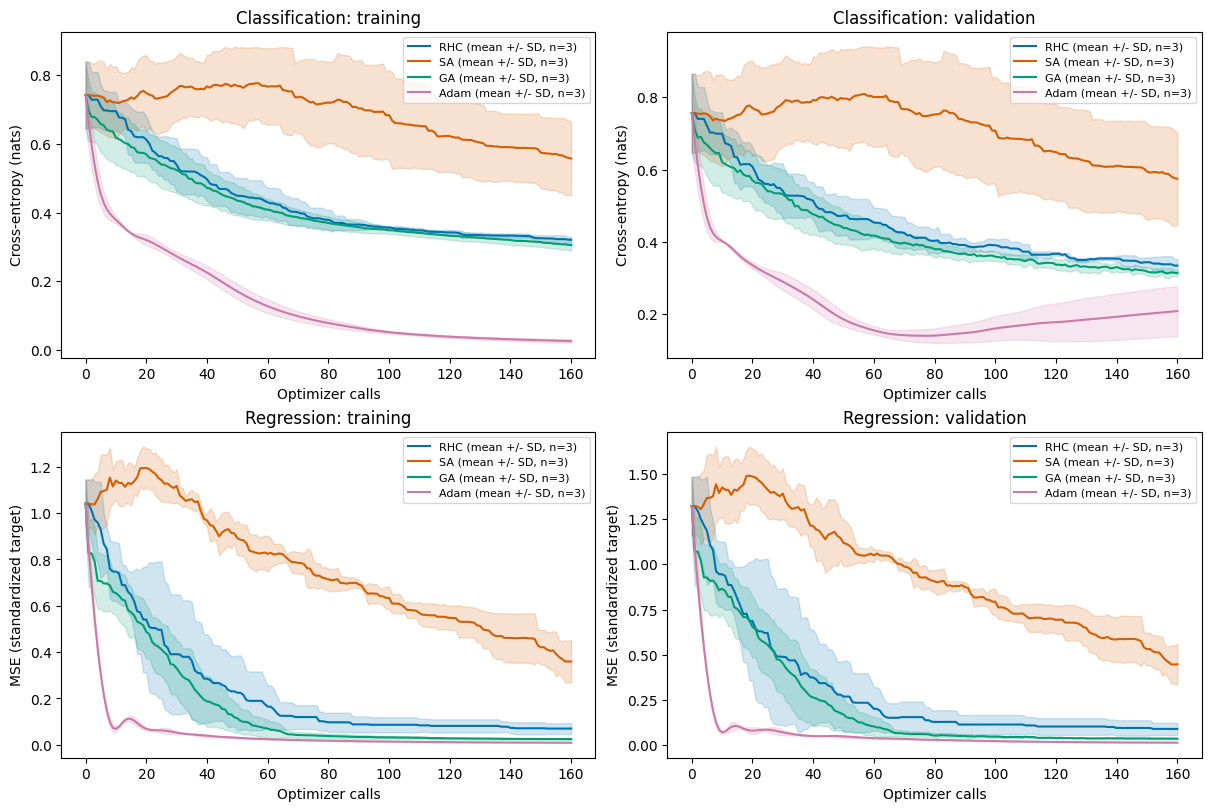

In [3]:
x = np.arange(CALLS + 1)
colors = {"RHC": "#0072B2", "SA": "#D55E00", "GA": "#009E73", "Adam": "#CC79A7"}
styles = {name: {"color": color} for name, color in colors.items()}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for row, (task, by_optimizer) in enumerate(results.items()):
    metric = (
        "Cross-entropy (nats)"
        if task == "Classification"
        else "MSE (standardized target)"
    )
    for col, split in enumerate(["train", "valid"]):
        values = {
            name: np.array([run_result[split] for run_result in runs]).T
            for name, runs in by_optimizer.items()
        }
        curve = prepare_training_curve(
            x,
            values,
            metric=metric,
            x_label="Optimizer calls",
        )
        plot_training_curve(curve, ax=axes[row, col], line_kwargs=styles)
        axes[row, col].set_title(
            f"{task}: {'training' if split == 'train' else 'validation'}"
        )
        axes[row, col].legend(fontsize=8)
plt.show()

RHC traces greedy local improvement with rejected-proposal plateaus. SA explores
more freely at high temperature, then becomes more selective. Elitist GA improves
the best retained population member generation by generation. Adam's gradient-driven
path is smoother in these runs. These observations describe the saved settings only;
the validation trajectories do not justify a general ranking.

## Replot by measured objective evaluations

GA evaluates 16 individuals at initialization, then eight new children per
generation because eight elite losses are reused. Its 160 calls therefore reach
1,288 measured fitness evaluations, while RHC, SA, and Adam each make 160 objective
calls here. Monitoring and Adam's backward work remain outside this axis.

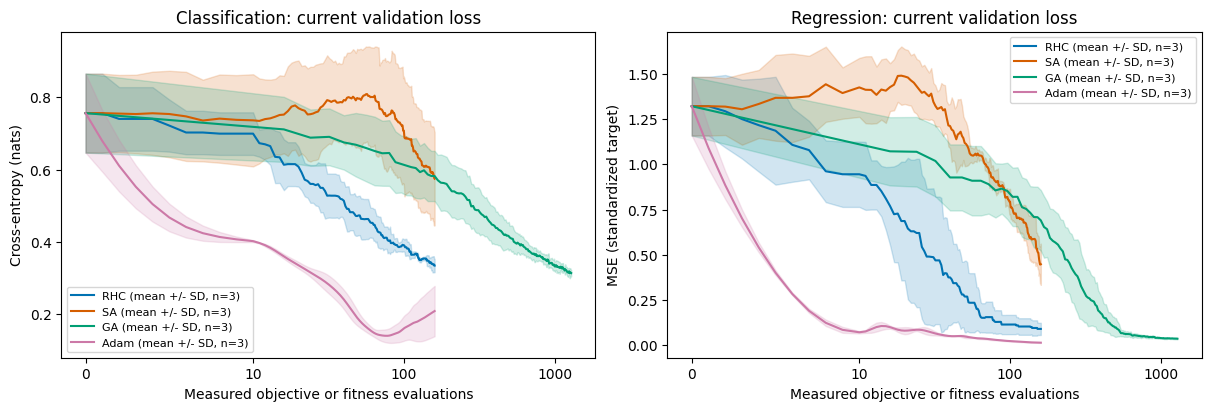

| Task | Optimizer | Proposals or generations | Measured evaluations | Restored validation loss | Accuracy or R² | F1 |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| Classification | RHC | 159 | 160 | 0.334 ± 0.018 | 0.863 ± 0.017 | 0.869 ± 0.017 |
| Classification | SA | 159 | 160 | 0.574 ± 0.129 | 0.678 ± 0.135 | 0.689 ± 0.115 |
| Classification | GA | 159 | 1288 | 0.313 ± 0.009 | 0.881 ± 0.017 | 0.887 ± 0.015 |
| Classification | Adam | n/a | 160 | 0.208 ± 0.070 | 0.948 ± 0.013 | 0.949 ± 0.012 |
| Regression | RHC | 159 | 160 | 0.090 ± 0.034 | 0.930 ± 0.026 | n/a |
| Regression | SA | 159 | 160 | 0.445 ± 0.107 | 0.656 ± 0.083 | n/a |
| Regression | GA | 159 | 1288 | 0.036 ± 0.004 | 0.972 ± 0.003 | n/a |
| Regression | Adam | n/a | 160 | 0.014 ± 0.001 | 0.989 ± 0.001 | n/a |

Each run also used 322 monitoring forwards and 1 restored validation forward.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, (task, by_optimizer) in zip(axes, results.items()):
    metric = (
        "Cross-entropy (nats)"
        if task == "Classification"
        else "MSE (standardized target)"
    )
    for name, runs in by_optimizer.items():
        grid = runs[0]["evals"]
        assert all(run_result["evals"] == grid for run_result in runs)
        curve = prepare_training_curve(
            grid,
            {name: np.array([run_result["valid"] for run_result in runs]).T},
            metric=metric,
            x_label="Measured objective or fitness evaluations",
        )
        plot_training_curve(curve, ax=ax, line_kwargs={name: styles[name]})
    ax.set_xscale("symlog", linthresh=10)
    ax.set_xticks([0, 10, 100, 1000], labels=["0", "10", "100", "1000"])
    ax.set_title(f"{task}: current validation loss")
    ax.legend(fontsize=8)
plt.show()


def mean_sd(values):
    values = np.asarray(values)
    return f"{values.mean():.3f} ± {values.std(ddof=1):.3f}"


rows = [
    "| Task | Optimizer | Proposals or generations | Measured evaluations | "
    "Restored validation loss | Accuracy or R² | F1 |",
    "| --- | --- | ---: | ---: | ---: | ---: | ---: |",
]
for task, by_optimizer in results.items():
    for name, runs in by_optimizer.items():
        summaries = [run_result["summary"] for run_result in runs]
        steps = summaries[0]["steps"]
        restored = mean_sd(
            [summary["restored_validation_loss"] for summary in summaries]
        )
        score = mean_sd([summary["score"] for summary in summaries])
        f1 = (
            mean_sd([summary["F1"] for summary in summaries])
            if task == "Classification"
            else "n/a"
        )
        rows.append(
            f"| {task} | {name} | {'n/a' if steps is None else steps} | "
            f"{summaries[0]['objective_calls']} | "
            f"{restored} | {score} | {f1} |"
        )
display(Markdown("\n".join(rows)))
print("Each run also used 322 monitoring forwards and 1 restored validation forward.")

The table reports restored checkpoints and variation across three runs. For RHC
and SA the step column counts proposals; for GA it counts generations after
population initialization. A generation is not one fitness evaluation, and none of
these budgets should be treated as equal time or equal compute.

## SA temperature and acceptance

The left panel separates current loss from best observed loss. The middle panel
shows deterministic cooling. The final panel groups proposals into 20-call blocks:
"Any accepted" includes improving and worse proposals, while "Worse accepted"
isolates uphill moves. Range ribbons show the observed minimum and maximum across
seeds.

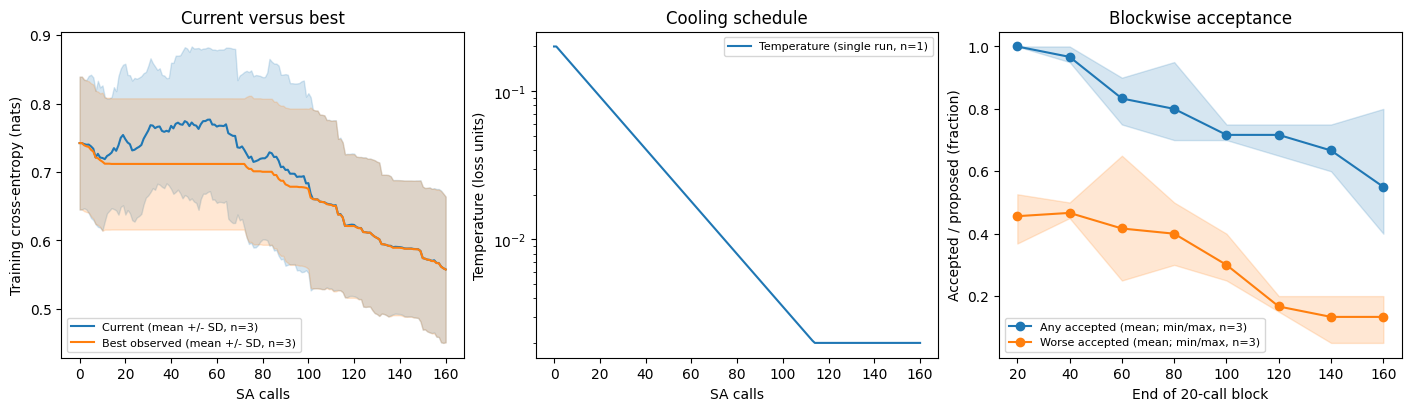

Mean worse-accepted fraction, first / last block: 0.456 / 0.133


In [5]:
runs = results["Classification"]["SA"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
curve = prepare_training_curve(
    x,
    {
        "Current": np.array([run_result["train"] for run_result in runs]).T,
        "Best observed": np.array([run_result["best"] for run_result in runs]).T,
    },
    metric="Training cross-entropy (nats)",
    x_label="SA calls",
)
plot_training_curve(curve, ax=axes[0])
plot_training_curve(
    prepare_training_curve(
        x,
        {"Temperature": runs[0]["temperature"]},
        metric="Temperature (loss units)",
        x_label="SA calls",
    ),
    ax=axes[1],
)
axes[1].set_yscale("log")

block_ends = np.arange(20, CALLS + 1, 20)


def block_rates(run_result, key):
    rates = []
    for start in range(1, CALLS + 1, 20):
        stop = min(start + 20, CALLS + 1)
        proposals = sum(run_result["proposal"][start:stop])
        rates.append(sum(run_result[key][start:stop]) / proposals)
    return rates


acceptance = {
    "Any accepted": np.array(
        [block_rates(run_result, "accepted") for run_result in runs]
    ).T,
    "Worse accepted": np.array(
        [block_rates(run_result, "worse_accepted") for run_result in runs]
    ).T,
}
plot_training_curve(
    prepare_training_curve(
        block_ends,
        acceptance,
        metric="Accepted / proposed (fraction)",
        x_label="End of 20-call block",
        uncertainty="range",
    ),
    ax=axes[2],
    line_kwargs={
        "Any accepted": {"marker": "o"},
        "Worse accepted": {"marker": "o"},
    },
)
for ax, title in zip(
    axes,
    ["Current versus best", "Cooling schedule", "Blockwise acceptance"],
):
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.show()
print(
    "Mean worse-accepted fraction, first / last block:",
    f"{acceptance['Worse accepted'][0].mean():.3f} / "
    f"{acceptance['Worse accepted'][-1].mean():.3f}",
)

The saved runs accept visibly worse moves early, creating separation between
current and best loss. Mean blockwise uphill acceptance falls from 0.456 in the
first block to 0.133 in the last as temperature reaches its floor, although the
decline is uneven across seeds. This supports the temperature-governed
interpretation without implying that SA must outperform another optimizer.

Next: [training, learning, and validation curves](03_learning_and_validation.ipynb).

In [6]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.77 seconds
